# Scientific Data Visualization: Galaxy Simulation Analysis

**Goal:** Most projects in this portfolio visualize business or web data.
This one is deliberately different — visualizing a raw N-body/SPH
(smoothed-particle hydrodynamics) galaxy simulation, the kind of data
astrophysicists work with directly. The point isn't a business
recommendation; it's demonstrating that the same visualization instincts
(pick the right chart for the question, label axes honestly, use scale
transforms when the data demands it) transfer to a completely different
data domain.

**Dataset:** [TipsyGalaxy](https://yt-project.org/data/TipsyGalaxy.tar.gz) —
a sample N-body/SPH galaxy simulation snapshot (Tipsy format) from the
[yt-project](https://yt-project.org/) data archive, containing ~315,000
gas, star, and dark matter particles.

**Tooling:** [`yt`](https://yt-project.org/) — a Python package purpose-built
for analyzing astrophysical simulation data (adaptive mesh refinement,
SPH particle data, etc.), on top of the usual matplotlib/numpy stack.

In [1]:
import yt
import numpy as np
import matplotlib.pyplot as plt
import os

BLUE, AQUA, ORANGE, RED, VIOLET = "#2a78d6", "#1baf7a", "#eb6834", "#e34948", "#4a3aa7"
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
CHART_DIR = "../assets"
os.makedirs(CHART_DIR, exist_ok=True)

## 1. Load the simulation snapshot

One snapshot (a single point in simulated time) of a galaxy formation
simulation — a mix of gas, star, and dark matter particles, each carrying
physical properties (mass, temperature, formation time, metallicity, ...).

In [2]:
ds = yt.load("../data/TipsyGalaxy/galaxy.00300")
df = ds.all_data()

gas_mass = df[("Gas", "Mass")]
star_mass = df[("Stars", "Mass")]
dm_mass = df[("DarkMatter", "Mass")]

print(f"Simulation time: {ds.current_time}")
print(f"Gas particles: {len(gas_mass):,}")
print(f"Star particles: {len(star_mass):,}")
print(f"Dark matter particles: {len(dm_mass):,}")
print(f"Total particles: {len(gas_mass) + len(star_mass) + len(dm_mass):,}")

yt : [INFO     ] 2026-07-18 19:46:48,287 Parameters: current_time              = 20.100000000000044


yt : [INFO     ] 2026-07-18 19:46:48,288 Parameters: domain_dimensions         = [1 1 1]


yt : [INFO     ] 2026-07-18 19:46:48,288 Parameters: domain_left_edge          = None


yt : [INFO     ] 2026-07-18 19:46:48,288 Parameters: domain_right_edge         = None


yt : [INFO     ] 2026-07-18 19:46:48,288 Parameters: cosmological_simulation   = 0.0


yt : [INFO     ] 2026-07-18 19:46:48,297 Allocating for 3.154e+05 particles


Simulation time: 20.100000000000044 code_time
Gas particles: 76,962
Star particles: 138,410
Dark matter particles: 100,000
Total particles: 315,372


## 2. When star particles formed

Every star particle records a formation time. A first pass at the raw
values shows something that looks like a bug: most star particles report
a formation time far *after* the simulation's current time (20.1). It
isn't a units mismatch (both fields are in the same `code_time` units,
checked directly) — it's ~81% of particles sharing the *exact same* value,
6706.9, which is the signature of a sentinel flag, not measured data.

112,508 / 138,410 star particles (81%) share formation_time > current_time (20.1) — a sentinel value marking pre-existing initial-condition stars, not stars that formed during the simulated period
Remaining 25,902 particles actually formed during the simulated 20.1 code_time units


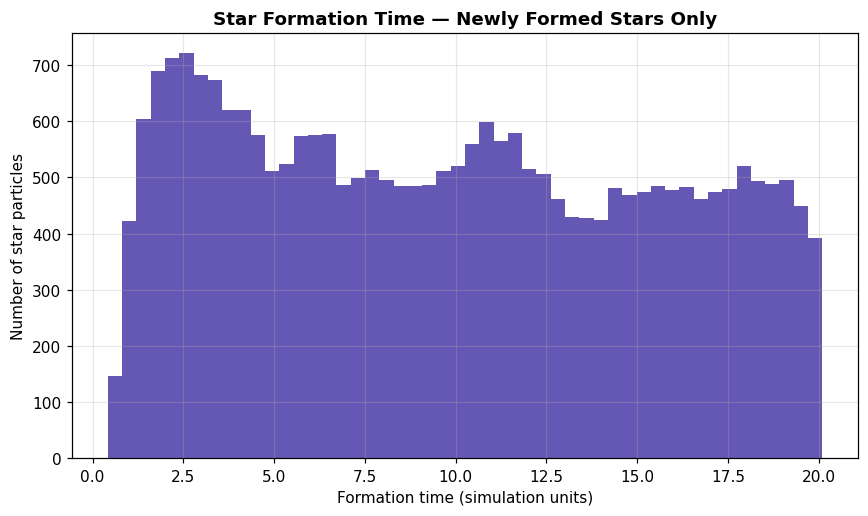

In [3]:
formation_times = df[("Stars", "FormationTime")].value
current_time = ds.current_time.value
n_preexisting = (formation_times > current_time).sum()
print(f"{n_preexisting:,} / {len(formation_times):,} star particles ({n_preexisting/len(formation_times):.0%}) share formation_time > current_time ({current_time:.1f}) — a sentinel value marking pre-existing initial-condition stars, not stars that formed during the simulated period")

valid_formation_times = formation_times[formation_times <= current_time]
print(f"Remaining {len(valid_formation_times):,} particles actually formed during the simulated 20.1 code_time units")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(valid_formation_times, bins=50, color=VIOLET, alpha=0.85)
ax.set_title("Star Formation Time — Newly Formed Stars Only", fontsize=12, fontweight="bold")
ax.set_xlabel("Formation time (simulation units)")
ax.set_ylabel("Number of star particles")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/star_formation_time.png", dpi=150)
plt.show()

Only about 1 in 5 stars in this snapshot actually formed during the
simulated window — the rest were part of the initial galaxy setup rather
than products of the simulation itself. Among the ~19% that did form
during the run, formation is heaviest early on and continues at a roughly
steady (if noisy) rate through to the current time — consistent with
ongoing star formation in an active galaxy, not a single formation burst.
Worth being explicit about which population a chart like this is actually
describing, since "star formation history" quietly meant two very
different things here depending on which 81%/19% split you're looking at.

## 3. Gas temperature distribution

Gas temperature spans many orders of magnitude in a galaxy simulation —
a linear axis would crush almost every particle into one bin next to a
handful of extreme outliers, so both axes need scale transforms here.

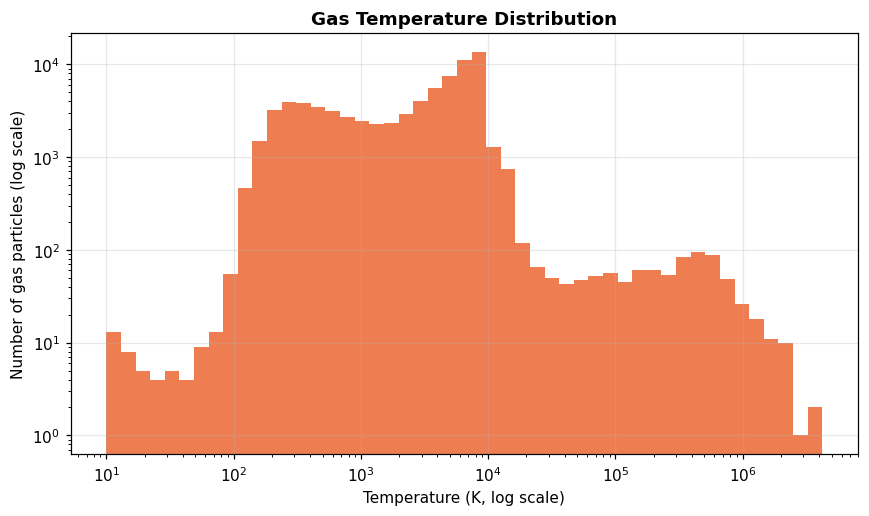

In [4]:
gas_temp = df[("Gas", "Temperature")].to("K").value

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(gas_temp, bins=np.logspace(np.log10(max(gas_temp.min(), 1)), np.log10(gas_temp.max()), 50), color=ORANGE, alpha=0.85)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Gas Temperature Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Temperature (K, log scale)")
ax.set_ylabel("Number of gas particles (log scale)")
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/gas_temperature.png", dpi=150)
plt.show()

Most gas sits in a cool, dense clump (the disk), with a long tail of
progressively hotter, rarer gas — shocked or diffuse gas heated by stellar
feedback and gravitational compression.

## 4. Spatial structure: where the gas actually is

Histograms describe *distributions*; they say nothing about *where* things
are in space. `yt`'s `ParticleProjectionPlot` splats raw SPH particle mass
onto a 2D grid and projects it along an axis — no need to first deposit
particles onto a mesh/octree index, which is the more fragile path for
this kind of unstructured particle data.

In [5]:
# Default framing shows the full simulation domain (1 Mpc box) — the galaxy
# itself is a tiny dot in it. Zooming to a 60 kpc window centered on the
# galaxy is what actually reveals its structure.
p = yt.ParticleProjectionPlot(ds, "z", ("Gas", "Mass"), center=[0.0, 0.045, 0.0], width=(60, "kpc"))
p.set_cmap(("Gas", "Mass"), "plasma")
p.save(f"{CHART_DIR}/gas_mass_projection.png")

yt : [INFO     ] 2026-07-18 19:46:49,188 xlim = -30.000000 30.000000


yt : [INFO     ] 2026-07-18 19:46:49,188 ylim = -29.955000 30.045000


yt : [INFO     ] 2026-07-18 19:46:49,189 xlim = -30.000000 30.000000


yt : [INFO     ] 2026-07-18 19:46:49,189 ylim = -29.955000 30.045000


yt : [INFO     ] 2026-07-18 19:46:49,190 Splatting (('Gas', 'Mass')) onto a 800 by 800 mesh using method 'ngp'


yt : [INFO     ] 2026-07-18 19:46:49,417 Saving plot ../assets/gas_mass_projection.png


['../assets/gas_mass_projection.png']

The spiral/disk structure is immediately visible here in a way no
histogram could show — this is the entire reason spatial visualization
tools like `yt` exist rather than just exporting particle tables to pandas.

## 5. Stellar mass vs. metallicity

Metallicity (the fraction of a star's mass that isn't hydrogen/helium)
tends to track a star's formation history — later-forming stars form from
gas already enriched by earlier generations of stars.

First pass at a log-log scatter of this blew up the y-axis to `1e-35`:
most star particles have metallicity of exactly `0.0`, and a handful of
floating-point-underflow values just above zero get log-transformed into
a meaningless vertical smear. Worth checking rather than plotting blind.

In [6]:
star_mass_msun = df[("Stars", "Mass")].to("Msun").value
star_metals = df[("Stars", "Metals")].value

n_zero = (star_metals == 0).sum()
print(f"{n_zero:,} / {len(star_metals):,} star particles ({n_zero/len(star_metals):.0%}) have exactly zero recorded metallicity")

112,632 / 138,410 star particles (81%) have exactly zero recorded metallicity


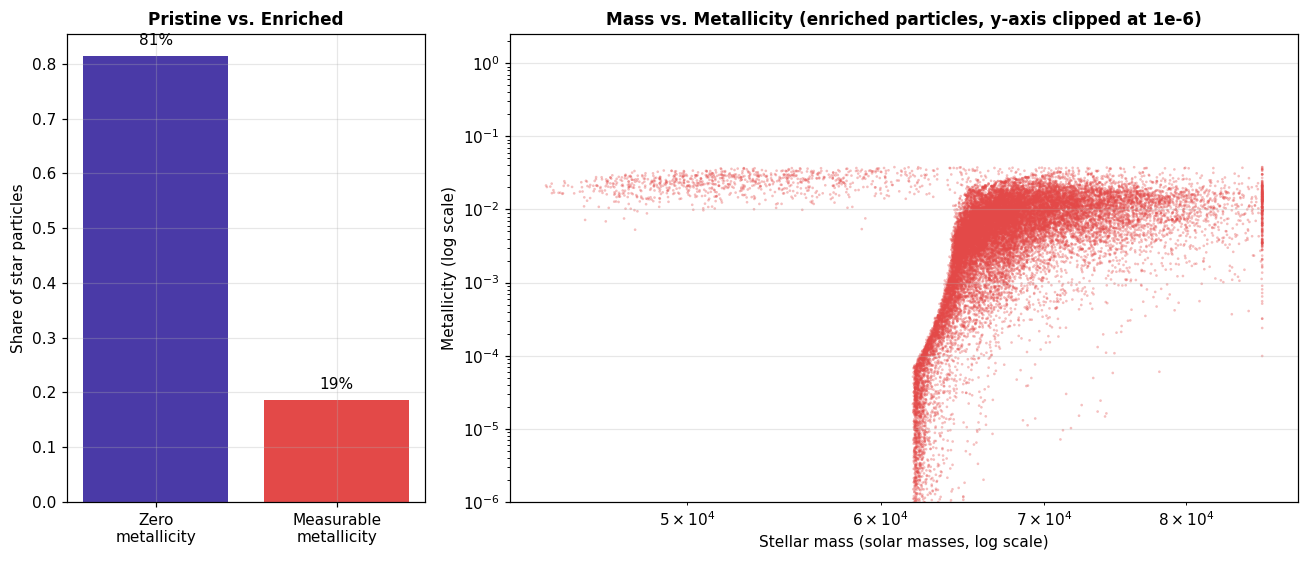

In [7]:
enriched = star_metals > 0
fig, axes = plt.subplots(1, 2, figsize=(12, 5.2), gridspec_kw={"width_ratios": [1, 2.2]})

pristine_pct = n_zero / len(star_metals)
axes[0].bar(["Zero\nmetallicity", "Measurable\nmetallicity"], [pristine_pct, 1 - pristine_pct], color=[VIOLET, RED])
axes[0].set_ylabel("Share of star particles")
axes[0].set_title("Pristine vs. Enriched", fontsize=11, fontweight="bold")
for i, v in enumerate([pristine_pct, 1 - pristine_pct]):
    axes[0].text(i, v + 0.02, f"{v:.0%}", ha="center", fontsize=10)

axes[1].scatter(star_mass_msun[enriched], star_metals[enriched], s=3, alpha=0.35, color=RED, edgecolors="none")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
# The >0 tail is a smooth continuum down to numerical-precision noise, not a
# clean signal/noise split — rather than pick an arbitrary data cutoff,
# clip the axis display range and say so, instead of letting a handful of
# ~1e-30 values stretch the whole plot into unreadability
axes[1].set_ylim(bottom=1e-6)
axes[1].set_title("Mass vs. Metallicity (enriched particles, y-axis clipped at 1e-6)", fontsize=11, fontweight="bold")
axes[1].set_xlabel("Stellar mass (solar masses, log scale)")
axes[1].set_ylabel("Metallicity (log scale)")

plt.tight_layout()
plt.savefig(f"{CHART_DIR}/mass_vs_metallicity.png", dpi=150)
plt.show()

Roughly 4 in 5 star particles carry exactly zero recorded metallicity —
either an early, pristine population that formed before significant
chemical enrichment, or a simplification of this particular simulation
setup (metal production/tracking is often simplified in lighter-weight
galaxy formation runs). The remaining "enriched" particles aren't cleanly
separated from zero either — they form a smooth continuum down to
numerical-precision noise (values like `1e-30`), so there's no principled
place to draw a hard cutoff. Clipping the display range and saying so is
more honest than either hiding that noise or letting it dominate the plot.

## Takeaway

None of these charts required a business framing to be worth building
correctly — the underlying skill (matching the chart to the question,
choosing linear vs. log scales based on what the data actually looks like,
not overplotting noisy sub-populations, layering a spatial view on top of
distributions when spatial structure is the actual question) is the same
skill used everywhere else in this portfolio, just pointed at a dataset
with zero customers, revenue, or business metrics in it.